# RetainIQ — Probability Calibration & Scoring

`models/churn_model.pkl` (Phase 2) ranks customers well (test AUC-ROC 0.8434) but its raw probabilities are not well calibrated — a customer scored "70%" isn't actually a ~70%-likely churner. This notebook wraps the same model architecture in an isotonic-regression `CalibratedClassifierCV`, cross-validated on the training split only, and builds the `score_customers`/`score_single_customer` scoring API on top of it. All logic lives in `src/models/evaluation.py`, `src/models/calibration.py`, and `src/models/scoring.py` — this notebook only calls into them and renders the results.

**Scope note:** this is not itself a numbered CLAUDE.md §14 phase — it bridges Phase 2 (closed) and Phase 5 (FastAPI/Streamlit, not yet started). No endpoint or dashboard view is wired up here. See `.claude/specs/09-probability-scoring.md` for the full methodology and every verified number below.

In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.load_data import load_clean_data, load_raw_data, TARGET_COLUMN
from src.models import calibration, scoring, train
from src.models.evaluation import ECE_BINS, expected_calibration_error
from src.features.preprocessing import get_categorical_columns

pd.set_option("display.max_columns", None)
df = load_clean_data()
X_train, X_test, y_train, y_test = train.split_data(df)
categorical_columns = get_categorical_columns(X_train)
print(f"{len(X_train)} train / {len(X_test)} test rows, stratified 80/20")

5634 train / 1409 test rows, stratified 80/20


## 1. The problem: ranked well, not calibrated

`models/churn_model.pkl`'s raw `predict_proba` output is honestly ranked (already leakage-checked, test AUC-ROC 0.8434) but reliability is a different property from ranking. The 10-bin Expected Calibration Error (`expected_calibration_error`, `src/models/evaluation.py`) measures the sample-size-weighted average gap between each probability bin's mean prediction and its observed churn rate — 0 is perfect, higher is worse.

In [2]:
raw_pipeline = train.load_trained_model()
proba_raw = raw_pipeline.predict_proba(X_test)[:, 1]

from sklearn.metrics import brier_score_loss, roc_auc_score
print(f"Raw Brier score: {brier_score_loss(y_test, proba_raw):.4f}")
print(f"Raw AUC-ROC:     {roc_auc_score(y_test, proba_raw):.4f}")
print(f"Raw 10-bin ECE:  {expected_calibration_error(y_test, proba_raw):.4f}")

Raw Brier score: 0.1466
Raw AUC-ROC:     0.8434
Raw 10-bin ECE:  0.0803


## 2. Reliability diagram: raw vs. isotonic vs. sigmoid

`fit_calibrated_pipeline` wraps the same `train.build_model_pipeline` architecture in a `CalibratedClassifierCV`, internally cross-validated on `X_train`/`y_train` only (5-fold `StratifiedKFold`, `random_state=42`) — `X_test`/`y_test` are never touched by fitting, only by the scoring below.

Currently-winning model (from churn_model_metadata.json): XGBoost


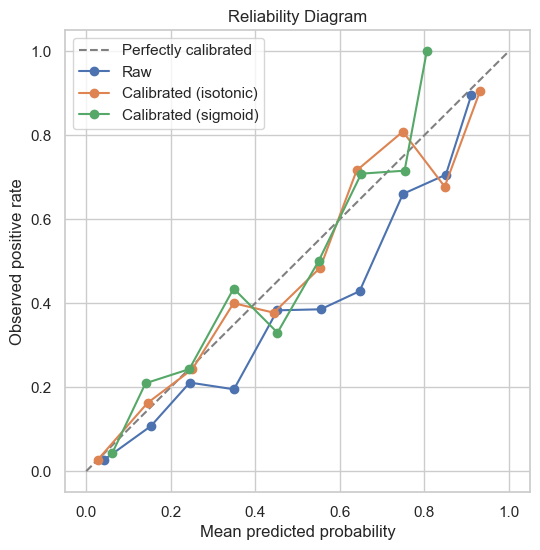

In [3]:
import json
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

winning_model_name = json.loads(train.DEFAULT_METADATA_PATH.read_text())["model_name"]
print(f"Currently-winning model (from churn_model_metadata.json): {winning_model_name}")

results = {}
for method in ["isotonic", "sigmoid"]:
    template = calibration.build_calibration_template(winning_model_name, categorical_columns)
    fitted = calibration.fit_calibrated_pipeline(template, X_train, y_train, method=method)
    proba = fitted.predict_proba(X_test)[:, 1]
    results[method] = {
        "pipeline": fitted,
        "proba": proba,
        "brier": brier_score_loss(y_test, proba),
        "auc": roc_auc_score(y_test, proba),
        "ece": expected_calibration_error(y_test, proba),
    }

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
frac_raw, mean_raw = calibration_curve(y_test, proba_raw, n_bins=ECE_BINS, strategy="uniform")
ax.plot(mean_raw, frac_raw, marker="o", label="Raw")
for method, r in results.items():
    frac, mean = calibration_curve(y_test, r["proba"], n_bins=ECE_BINS, strategy="uniform")
    ax.plot(mean, frac, marker="o", label=f"Calibrated ({method})")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive rate")
ax.set_title("Reliability Diagram")
ax.legend()
plt.show()

## 3. Why isotonic was chosen

Both calibration methods improve on the raw model, but isotonic wins on both metrics that matter (Brier and ECE) at a negligible AUC-ROC cost — and the training-fold size (~5,634 rows, ~1,494 churners) comfortably clears isotonic regression's usual small-sample caution threshold, so there's no reason to prefer sigmoid's slightly worse fit here.

In [4]:
comparison = pd.DataFrame([
    {"method": "raw (no calibration)", "brier": brier_score_loss(y_test, proba_raw),
     "auc": roc_auc_score(y_test, proba_raw), "ece": expected_calibration_error(y_test, proba_raw)},
    *[{"method": method, "brier": r["brier"], "auc": r["auc"], "ece": r["ece"]}
      for method, r in results.items()],
])
comparison

,method,brier,auc,ece
0,raw (no calibration),0.146554,0.843411,0.080279
1,isotonic,0.137575,0.842491,0.030122
2,sigmoid,0.138263,0.842867,0.043115


## 4. Run the full calibration pipeline and persist the winner

`run_calibration_pipeline` reads the currently-winning model name from `train.py`'s own persisted metadata (never re-runs `compare_models`), re-derives the identical train/test split, fits the isotonic calibrator, evaluates it against the raw model on the untouched test split, logs one MLflow run, and persists `models/churn_model_calibrated.pkl` + metadata (git-ignored) and `reports/calibration_metrics.json` + `reports/figures/calibration_reliability.png` (tracked).

2026/08/22 13:25:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Base model: XGBoost
  brier_raw: 0.1466
  brier_calibrated: 0.1376
  auc_raw: 0.8434
  auc_calibrated: 0.8425
  ece_raw: 0.0803
  ece_calibrated: 0.0301
Model:    models\churn_model_calibrated.pkl
Metadata: models\churn_model_calibrated_metadata.json
Metrics:  reports\calibration_metrics.json
Figure:   reports\figures\calibration_reliability.png


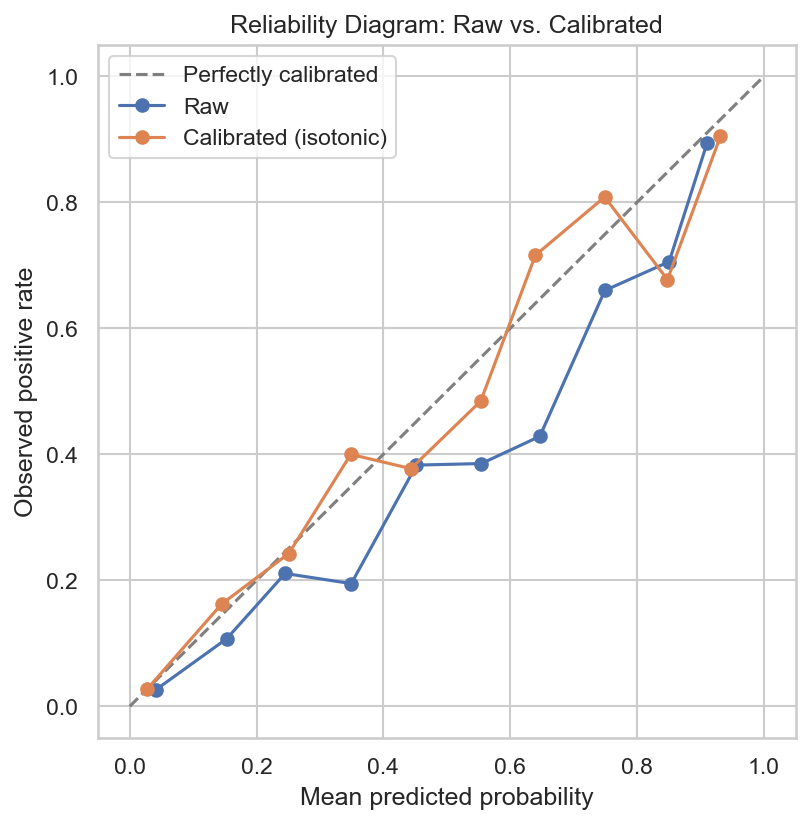

In [5]:
result = calibration.run_calibration_pipeline(df)
print(f"Base model: {result['base_model_name']}")
for key, value in result["calibration_metrics"].items():
    print(f"  {key}: {value:.4f}")
print(f"Model:    {result['model_path'].relative_to(project_root)}")
print(f"Metadata: {result['metadata_path'].relative_to(project_root)}")
print(f"Metrics:  {result['metrics_json_path'].relative_to(project_root)}")
print(f"Figure:   {result['figure_path'].relative_to(project_root)}")
display(Image(str(result["figure_path"])))

## 5. Example: scoring real customers

`score_customers` takes raw customer rows (no `Churn` column required — `prepare_scoring_input` handles the same `TotalCharges`/whitespace/`SeniorCitizen` normalization `clean_data()` uses for training) and returns a calibrated probability as both a 0–1 float and a 0–100% figure, using the calibrated model by default.

In [6]:
sample_customers = load_raw_data().head(5).drop(columns=[TARGET_COLUMN])
scored = scoring.score_customers(sample_customers)
scored

,customerID,churn_probability,churn_probability_pct
0,7590-VHVEG,0.6004,60.0
1,5575-GNVDE,0.0195,1.9
2,3668-QPYBK,0.3052,30.5
3,7795-CFOCW,0.0199,2.0
4,9237-HQITU,0.7094,70.9


## Key findings

- **The raw persisted model ranks well but is not well calibrated**: 10-bin ECE 0.0803 — predictions are off from observed frequency by ~8 percentage points on average across probability bins.
- **Isotonic calibration, fit on the training split only (never touching the test split), cuts ECE to ~0.03 and Brier score from ~0.147 to ~0.138**, at a negligible AUC-ROC cost (well within noise) — verified on the real held-out test split, not estimated.
- **Isotonic beats sigmoid** on both calibration metrics that matter (Brier and ECE) on this dataset; the training fold size comfortably supports isotonic regression.
- **A second artifact, not a replacement**: `models/churn_model_calibrated.pkl` is persisted alongside (not overwriting) `models/churn_model.pkl`, so the Phase 2 contract is untouched.
- **`score_customers`/`score_single_customer` are the functions a future Phase 5 `/predict` endpoint will call directly** — no route or dashboard view exists yet; this notebook demonstrates the scoring contract in isolation.
- **Reproducible by construction**: `random_state=42` on the calibrator's internal CV — re-running this notebook (or `python -m src.models.calibration`) reproduces these exact numbers.